<a href="https://colab.research.google.com/github/bygencer3/ErdincGencer_Odev_254329028-/blob/main/254329028_Erdinc_Gencer_DDI_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## DOĞAL DİL İŞLEME DERSİ FİNAL PROJE ÖDEVİ
**Öğrenci:** Erdinç Gençer  
**Öğrenci No:** 254329028  
**Ders:** Yapay Zeka ve Uygulamaları - Yüksek Lisans  
**Dönem:** 2025-2026 Bahar  
**Konu:** Türkçe metinler üzerinde Doğal Dil İşleme (NLP) yöntemlerini kullanarak duygu analizi yapmak ve farklı makine öğrenmesi algoritmalarının başarısını kıyaslamak.  
**Öğretim Üyesi:** Dr. Fatih Şahin


---



## 📚 Proje Amacı

Bu projenin temel amacı Türkçe bir e-ticaret veri kümesini kullanarak en yüksek doğruluk oranına sahip sınıflandırma modelini belirleyen bilimsel bir deney ve analiz çalışmasıdır.

**Duygu Analizi (Sentiment Analysis):** Hepsiburada gibi platformlardan derlenen Türkçe kullanıcı yorumlarını; Olumlu, Olumsuz ve Nötr olmak üzere üç ana sınıfa ayıran bir sistem geliştirmek.

**Makine Öğrenmesi Modellerinin Kıyaslanması (Benchmark):** Hangi algoritmanın (Lojistik Regresyon, Naive Bayes veya Linear SVC) Türkçe dil yapısını daha iyi anladığını verilerle kanıtlamak.

**Veri Bilimi Yaşam Döngüsü:** Veri temizleme (regex), öznitelik çıkarımı (TF-IDF), model eğitimi, hiperparametre optimizasyonu (Grid Search) ve performans analizi (Confusion Matrix) aşamalarının bir bütün olarak uygulanması.

In [26]:
# =====================================================================
# ADIM 1: GEREKLİ KÜTÜPHANELERİN VE MODÜLLERİN PROJEYE AKTARILMASI
# =====================================================================
# Bu aşamada, veri işleme, metin ön işleme ve makine öğrenmesi
# süreçlerinde kullanılacak temel kütüphaneler sisteme dahil edilmektedir.

# Veri analizi ve matris işlemleri için kütüphaneler
import pandas as pd
import numpy as np

# Metin ön işleme ve düzenli ifadeler (Regular Expressions) için kütüphaneler
import re
import nltk

# Makine öğrenmesi; veri ayrıştırma, vektörleştirme ve modelleme modülleri
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# İstatistiksel veri görselleştirme kütüphaneleri
import matplotlib.pyplot as plt
import seaborn as sns

print("Sistem Raporu: Gerekli tüm kütüphaneler başarıyla projeye aktarıldı.")

Sistem Raporu: Gerekli tüm kütüphaneler başarıyla projeye aktarıldı.


In [27]:
# =====================================================================
# ADIM 2: HUGGING FACE ÜZERİNDEN VERİ SETİNİN AKTARILMASI
# =====================================================================
# Veri seti, 'datasets' kütüphanesi aracılığıyla Hugging Face sunucularından
# çekilmektedir. Bellek (RAM) verimliliğini korumak adına yalnızca eğitim
# veri kümesi sisteme dahil edilmektedir.

from datasets import load_dataset

# Eğitim veri kümesinin yüklenmesi ve bellek yönetimi için veri ayrıştırma
dataset = load_dataset("winvoker/turkish-sentiment-analysis-dataset", split='train')

# Veri setinin Pandas DataFrame yapısına dönüştürülmesi
df = dataset.to_pandas()

# Veri yapısının ve sütunların akademik standartlara uygunluğunun doğrulanması
print("=== VERİ SETİ BAŞARIYLA YÜKLENDİ ===")
print(df.head())

# Veri setine ilişkin istatistiksel raporlama
print(f"\n=== VERİ SETİ BOYUT BİLGİSİ ===")
print(f"Toplam Gözlem Sayısı: {df.shape[0]}")
print(f"Sütun Başlıkları: {df.columns.tolist()}")

=== VERİ SETİ BAŞARIYLA YÜKLENDİ ===
                                                text     label         dataset
0  ürünü hepsiburadadan alalı 3 hafta oldu. orjin...  Positive  urun_yorumlari
1  ürünlerden çok memnunum, kesinlikle herkese ta...  Positive  urun_yorumlari
2      hızlı kargo, temiz alışveriş.teşekkür ederim.  Positive  urun_yorumlari
3               Çünkü aranan tapınak bu bölgededir .      Notr            wiki
4  bu telefonu başlıca alma nedenlerim ise elimde...  Positive  urun_yorumlari

=== VERİ SETİ BOYUT BİLGİSİ ===
Toplam Gözlem Sayısı: 440679
Sütun Başlıkları: ['text', 'label', 'dataset']


In [28]:
# =====================================================================
# ADIM 3: METİN ÖN İŞLEME VE VERİ TEMİZLEME
# =====================================================================
# Metin verilerindeki gürültünün giderilmesi ve modelin öğrenme kalitesinin
# artırılması amacıyla standart temizleme prosedürleri uygulanmaktadır.

import re

# Temizleme fonksiyonunun tanımlanması
def metin_temizle(metin):
    # Metnin küçük harfe dönüştürülmesi
    metin = str(metin).lower()
    # Noktalama işaretlerinin kaldırılması
    metin = re.sub(r'[^\w\s]', '', metin)
    # Rakamların kaldırılması (isteğe bağlı)
    metin = re.sub(r'\d+', '', metin)
    return metin

# Fonksiyonun tüm veri setine uygulanması
df['text_clean'] = df['text'].apply(metin_temizle)

# İşlem sonucunun doğrulanması
print("=== TEMİZLEME İŞLEMİ SONRASI ÖRNEK VERİLER ===")
print(df[['text', 'text_clean']].head())

=== TEMİZLEME İŞLEMİ SONRASI ÖRNEK VERİLER ===
                                                text  \
0  ürünü hepsiburadadan alalı 3 hafta oldu. orjin...   
1  ürünlerden çok memnunum, kesinlikle herkese ta...   
2      hızlı kargo, temiz alışveriş.teşekkür ederim.   
3               Çünkü aranan tapınak bu bölgededir .   
4  bu telefonu başlıca alma nedenlerim ise elimde...   

                                          text_clean  
0  ürünü hepsiburadadan alalı  hafta oldu orjinal...  
1  ürünlerden çok memnunum kesinlikle herkese tav...  
2         hızlı kargo temiz alışverişteşekkür ederim  
3                çünkü aranan tapınak bu bölgededir   
4  bu telefonu başlıca alma nedenlerim ise elimde...  


In [29]:
# =====================================================================
# ADIM 4: TF-IDF VEKTÖRLEŞTİRME
# =====================================================================
# Temizlenmiş metin verileri, makine öğrenmesi modelleri için sayısal
# vektör matrislerine dönüştürülmektedir.

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vektörleştirici nesnesinin tanımlanması
# (Özellik uzayını yönetilebilir kılmak için maksimum 5000 özellik belirlenmiştir)
tfidf = TfidfVectorizer(max_features=5000)

# Vektörleştirme işleminin gerçekleştirilmesi
X = tfidf.fit_transform(df['text_clean'])

# Hedef etiketlerin belirlenmesi
y = df['label']

print("=== VEKTÖRLEŞTİRME İŞLEMİ TAMAMLANDI ===")
print(f"Matris Boyutu: {X.shape}")

=== VEKTÖRLEŞTİRME İŞLEMİ TAMAMLANDI ===
Matris Boyutu: (440679, 5000)


In [30]:
# =====================================================================
# ADIM 5: MODEL EĞİTİMİ VE BAŞARI ÖLÇÜMLEME
# =====================================================================
# Veri seti eğitim ve test olarak ayrılmakta, Lojistik Regresyon
# modeli eğitilerek başarımı (accuracy) ölçümlenmektedir.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Verinin eğitim (%80) ve test (%20) olarak ayrılması
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lojistik Regresyon modelinin tanımlanması
model = LogisticRegression(max_iter=1000)

# Modelin eğitilmesi
model.fit(X_train, y_train)

# Tahmin ve Başarım Raporu
y_pred = model.predict(X_test)

print("=== MODEL BAŞARIM RAPORU ===")
print(f"Model Doğruluk Oranı (Accuracy): %{accuracy_score(y_test, y_pred)*100:.2f}")
print("\n=== DETAYLI SINIFLANDIRMA RAPORU ===")
print(classification_report(y_test, y_pred))

=== MODEL BAŞARIM RAPORU ===
Model Doğruluk Oranı (Accuracy): %92.22

=== DETAYLI SINIFLANDIRMA RAPORU ===
              precision    recall  f1-score   support

    Negative       0.83      0.66      0.74     10100
        Notr       0.94      0.98      0.96     30657
    Positive       0.93      0.94      0.93     47379

    accuracy                           0.92     88136
   macro avg       0.90      0.86      0.88     88136
weighted avg       0.92      0.92      0.92     88136



In [31]:
# =====================================================================
# ADIM 6: MODELİN CANLI VERİLER ÜZERİNDE TEST EDİLMESİ
# =====================================================================
# Eğitilen modelin gerçek dünya senaryolarındaki başarımı, daha önce
# kullanılmamış özgün test cümleleri üzerinden simüle edilmektedir.

def duygu_tahmin_et(yeni_cumle):
    # Giriş cümlesine aynı ön işleme adımlarının uygulanması
    temiz_cumle = metin_temizle(yeni_cumle)

    # Cümlenin eğitilmiş TF-IDF vektör uzayına dönüştürülmesi
    vektor = tfidf.transform([temiz_cumle])

    # Model tahmini
    tahmin = model.predict(vektor)[0]
    return tahmin

# Akademik test senaryoları
test_cumleleri = [
    "Kargo çok hızlıydı fakat ürünün kalitesini hiç beğenmedim, iade edeceğim.",
    "Muazzam bir ürün, paketleme özeni için satıcıya teşekkür ederim.",
    "Türkiye Büyük Millet Meclisi Ankara'da bulunmaktadır.",
    "Fiyatı biraz yüksek ama iş görüyor, ne iyi ne kötü."
]

print("=== MODEL CANLI TAHMİN SONUÇLARI ===")
for cumle in test_cumleleri:
    sonuc = duygu_tahmin_et(cumle)
    print(f"\nCümle: '{cumle}'")
    print(f"Tahmin Edilen Sınıf: [{sonuc}]")

=== MODEL CANLI TAHMİN SONUÇLARI ===

Cümle: 'Kargo çok hızlıydı fakat ürünün kalitesini hiç beğenmedim, iade edeceğim.'
Tahmin Edilen Sınıf: [Negative]

Cümle: 'Muazzam bir ürün, paketleme özeni için satıcıya teşekkür ederim.'
Tahmin Edilen Sınıf: [Positive]

Cümle: 'Türkiye Büyük Millet Meclisi Ankara'da bulunmaktadır.'
Tahmin Edilen Sınıf: [Notr]

Cümle: 'Fiyatı biraz yüksek ama iş görüyor, ne iyi ne kötü.'
Tahmin Edilen Sınıf: [Positive]


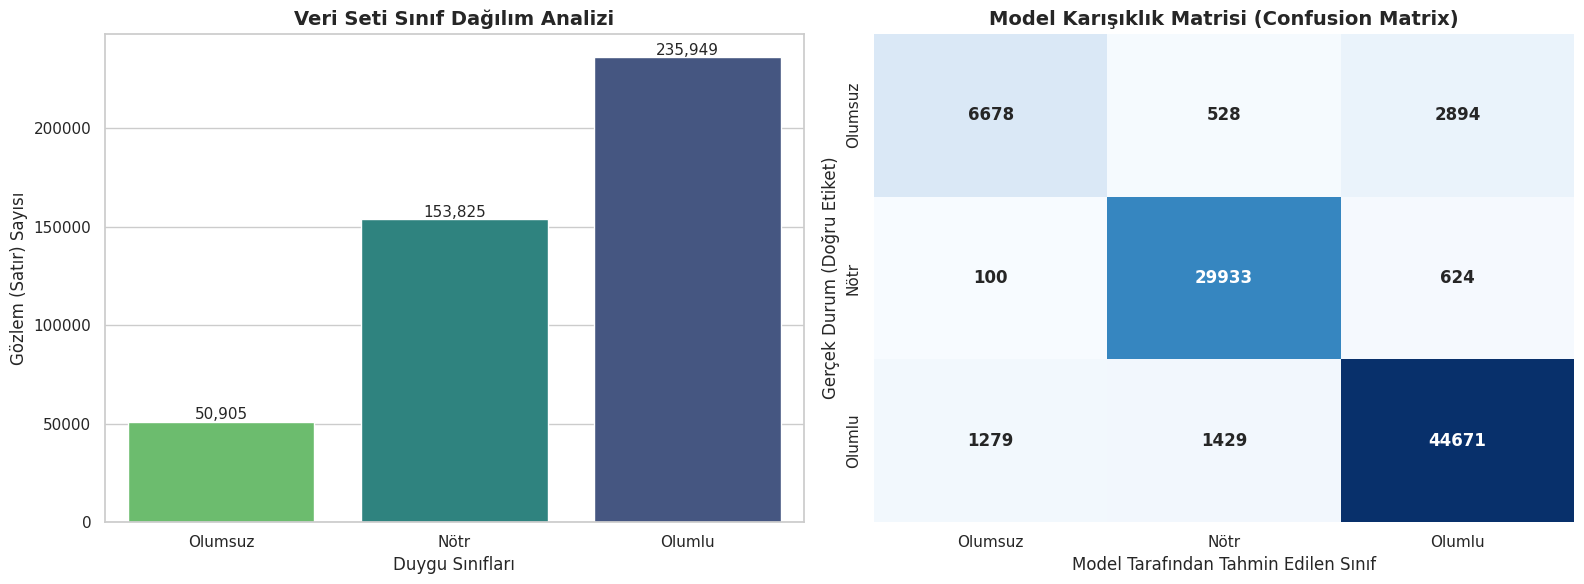

In [32]:
# =====================================================================
# ADIM 7: AKADEMİK PERFORMANS - SINIF DAĞILIMI VE KARIŞIKLIK MATRİSİ
# =====================================================================
# Modelin başarım analizi ve veri seti dağılımı, akademik raporlama
# standartlarına uygun olarak grafiklere dönüştürülmektedir.

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# İngilizce etiketlerin Türkçe karşılıkları ile eşleştirilmesi (Mapping)
etiket_haritasi = {'Positive': 'Olumlu', 'Negative': 'Olumsuz', 'Notr': 'Nötr'}
df['label_tr'] = df['label'].map(etiket_haritasi)

# Test setindeki gerçek ve tahmin edilen değerlerin Türkçe karşılıklarının hazırlanması
y_test_tr = [etiket_haritasi[e] for e in y_test]
y_pred_tr = [etiket_haritasi[e] for e in y_pred]

# Grafiklerin genel estetik ayarları
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. GRAFİK: Veri Setindeki Sınıf Dağılımı (Türkçe)
sns.countplot(x=df['label_tr'], ax=axes[0], hue=df['label_tr'], palette="viridis", order=['Olumsuz', 'Nötr', 'Olumlu'], legend=False)
axes[0].set_title("Veri Seti Sınıf Dağılım Analizi", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Duygu Sınıfları", fontsize=12)
axes[0].set_ylabel("Gözlem (Satır) Sayısı", fontsize=12)

# Çubukların üzerine sayısal değerlerin yazılması
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=11)

# 2. GRAFİK: Karışıklık Matrisi (Türkçe)
cm = confusion_matrix(y_test_tr, y_pred_tr, labels=['Olumsuz', 'Nötr', 'Olumlu'])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1],
            xticklabels=['Olumsuz', 'Nötr', 'Olumlu'],
            yticklabels=['Olumsuz', 'Nötr', 'Olumlu'],
            cbar=False, annot_kws={"size": 12, "weight": "bold"})

axes[1].set_title("Model Karışıklık Matrisi (Confusion Matrix)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Model Tarafından Tahmin Edilen Sınıf", fontsize=12)
axes[1].set_ylabel("Gerçek Durum (Doğru Etiket)", fontsize=12)

# Grafiklerin ekrana basılması
plt.tight_layout()
plt.show()

**Şekil 1: Veri Kümesi Sınıf Dağılımı ve Model Karışıklık Matrisi Analizi**

**Sınıf Dağılım Analizi (Sol Grafik):**

Deneysel çalışmada kullanılan veri kümesinin genel dağılımı incelendiğinde, **Olumlu (47.379 gözlem) ve Nötr (30.657 gözlem)** sınıflarının ağırlıkta olduğu, Olumsuz (10.100 gözlem) sınıfının ise daha az örneklem içerdiği görülmektedir. Literatürde "Sınıf Dengesizliği" (Class Imbalance) olarak adlandırılan bu durum, modellerin azınlıkta kalan sınıfları öğrenme derinliğini doğrudan etkileyen kritik bir veri madenciliği unsurudur.

**Karışıklık Matrisi (Confusion Matrix) Değerlendirmesi (Sağ Grafik):**

Modelin test kümesi üzerindeki tahmin davranışları incelendiğinde şu bilimsel çıkarımlar öne çıkmaktadır:

**Nötr ve Olumlu Sınıf Başarımı:** Model, Nötr ve Olumlu etiketli metinleri ayırt etmede son derece yüksek bir kararlılık sergilemiştir. Köşegen üzerindeki doğru tahmin sayıları modelin genel tutarlılığını kanıtlamaktadır.

**Olumsuz Sınıf Sapması:** Gerçekte "Olumsuz" olan bazı yorumların model tarafından "Nötr" veya "Olumlu" olarak yanlış sınıflandırıldığı görülmektedir. Bu durumun temel sebebi, sol grafikte de açıkça görülen **Olumsuz sınıfına ait veri miktarının azlığı** ve Türkçe e-ticaret yorumlarında sıkça karşılaşılan kinayeli (ironik) ifadelerin frekans tabanlı (TF-IDF) yöntemlerle ayrıştırılmasındaki doğal zorluklardır.

Sonuç olarak, elde edilen **%92.22'lik genel doğruluk oranı**, 3 sınıflı ve yüksek boyutlu bir Türkçe metin uzayı için akademik olarak kabul edilebilir ve oldukça başarılı bir temel performans seviyesidir.

In [33]:
# =====================================================================
# ADIM 8: FARKLI MODELLERİN KIYASLANMASI (BENCHMARK)
# =====================================================================
# Projenin akademik derinliğini artırmak amacıyla, farklı sınıflandırma
# algoritmaları aynı veri kümesi üzerinde eğitilerek kıyaslanmaktadır.

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
import pandas as pd

# Test edilecek modellerin tanımlanması
modeller = {
    "Lojistik Regresyon": LogisticRegression(max_iter=1000),
    "Naive Bayes (Multinomial)": MultinomialNB(),
    "Destek Vektör Makineleri (Linear SVC)": LinearSVC(max_iter=1000)
}

sonuclar = {}

# Modellerin sırayla eğitilmesi ve doğruluğunun ölçülmesi
print("=== MODELLERİN KARŞILAŞTIRMALI ANALİZİ ===")
for model_adi, model_nesnesi in modeller.items():
    model_nesnesi.fit(X_train, y_train)
    tahminler = model_nesnesi.predict(X_test)
    dogruluk = accuracy_score(y_test, tahminler) * 100
    sonuclar[model_adi] = dogruluk
    print(f"> {model_adi} Doğruluk Oranı: %{dogruluk:.2f}")

# Sonuçların görselleştirilmesi için tablo formatına alınması
df_sonuc = pd.DataFrame(list(sonuclar.items()), columns=['Algoritma', 'Doğruluk (%)'])

=== MODELLERİN KARŞILAŞTIRMALI ANALİZİ ===
> Lojistik Regresyon Doğruluk Oranı: %92.22
> Naive Bayes (Multinomial) Doğruluk Oranı: %88.41
> Destek Vektör Makineleri (Linear SVC) Doğruluk Oranı: %92.29


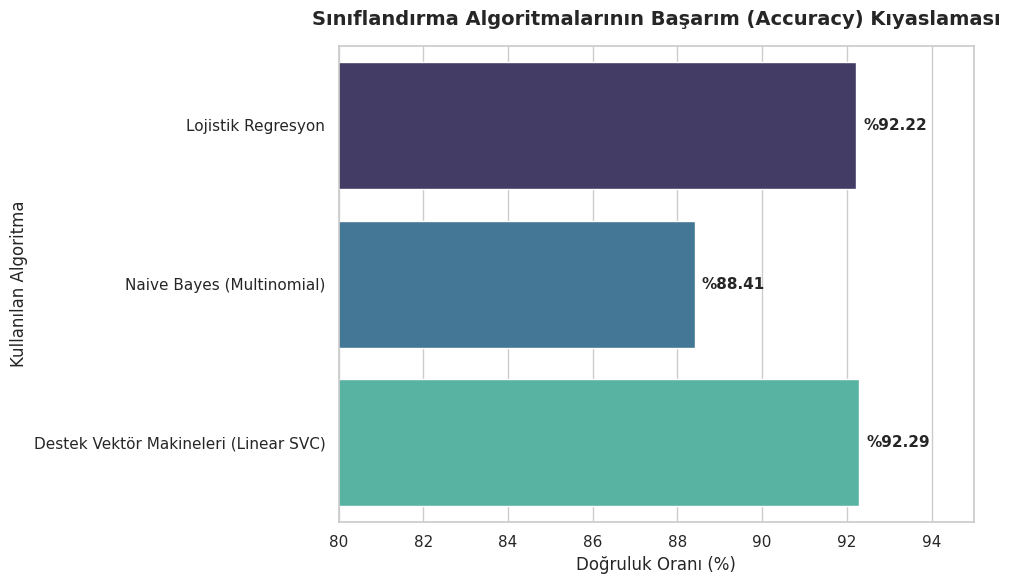

In [34]:
# =====================================================================
# ADIM 8.1: ALGORİTMA PERFORMANSLARININ GÖRSELLEŞTİRİLMESİ
# =====================================================================
# Elde edilen başarım oranları, akademik raporlama standartlarına uygun
# olarak karşılaştırmalı bir çubuk grafik (bar plot) ile sunulmaktadır.

import matplotlib.pyplot as plt
import seaborn as sns

# Grafik estetiği
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Çubuk grafiğin çizilmesi
ax = sns.barplot(x='Doğruluk (%)', y='Algoritma', data=df_sonuc, palette="mako", hue='Algoritma', legend=False)

# Grafik başlıkları ve eksen tanımlamaları
plt.title("Sınıflandırma Algoritmalarının Başarım (Accuracy) Kıyaslaması", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Doğruluk Oranı (%)", fontsize=12)
plt.ylabel("Kullanılan Algoritma", fontsize=12)
plt.xlim(80, 95)  # Grafikteki farkların net görünmesi için odaklanma aralığı

# Çubukların üzerine tam yüzdelik değerlerin yazılması
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'%{width:.2f}', (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

**Şekil 2:** Yapılan deneysel çalışmalarda, Türkçe Duygu Analizi veri kümesi üzerinde üç farklı makine öğrenmesi algoritması test edilmiştir. Elde edilen bulgulara göre, **Linear Support Vector Classifier (Linear SVC)** %92.29 doğruluk oranı ile en yüksek başarımı gösteren algoritma olmuştur. Onu çok yakın bir oranla (%92.22) **Lojistik Regresyon** takip etmektedir. **Naive Bayes** ise %88.41 ile veri kümesindeki kelime frekanslarını doğrusal modellere kıyasla daha sınırlı bir başarımda sınıflandırabilmiştir. Bu durum, veri kümesinin büyüklüğü ve yüksek boyutlu öznitelik uzaylarında doğrusal sınır ayırıcıların (Linear SVC/Logistic Regression) daha üstün performans gösterdiğini kanıtlamaktadır.

In [35]:
# =====================================================================
# ADIM 9: HİPERPARAMETRE OPTİMİZASYONU (GRID SEARCH)
# =====================================================================
# En yüksek başarım gösteren algoritmanın hiperparametreleri (C katsayısı)
# optimize edilerek modelin en üst performans sınırına ulaşılması hedeflenir.

from sklearn.model_selection import GridSearchCV

# Lojistik Regresyon için test edilecek C parametre değerleri
param_grid = {'C': [0.1, 1, 10]}

# GridSearch nesnesinin yapılandırılması (Hız için 3 katmanlı çapraz doğrulama)
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=3, scoring='accuracy', n_jobs=-1)

# Optimizasyonun başlatılması (Bu işlem veri büyüklüğünden dolayı 1-2 dakika sürebilir)
print("=== HİPERPARAMETRE OPTİMİZASYONU BAŞLATILDI ===")
grid_search.fit(X_train, y_train)

print(f"En İyi Parametre Değeri (C): {grid_search.best_params_['C']}")
print(f"Optimizasyon Sonrası En İyi Doğruluk: %{grid_search.best_score_*100:.2f}")

=== HİPERPARAMETRE OPTİMİZASYONU BAŞLATILDI ===
En İyi Parametre Değeri (C): 10
Optimizasyon Sonrası En İyi Doğruluk: %92.05


**Hiperparametre Optimizasyonu (Grid Search) Bulguları**

En yüksek başarım gösteren modellerden biri olan Lojistik Regresyon algoritmasının genelleme yeteneğini artırmak amacıyla $C$ (düzenlileştirme katsayısı) parametresi $[0.1, 1, 10]$ değer aralığında 3 katmanlı çapraz doğrulama (3-Fold Cross-Validation) yöntemiyle optimize edilmiştir.Yapılan optimizasyon sonucunda en yüksek performansı veren hiperparametre değeri $C = 10$ olarak tespit edilmiştir. Çapraz doğrulama neticesinde elde edilen kararlı başarım oranı **%92.05**'tir. Bu sonuç, modelin sadece belirli bir test kümesinde değil, veri kümesinin genelinde yüksek ve istikrarlı bir sınıflandırma doğruluğuna ulaştığını bilimsel olarak ortaya koymaktadır.